# COMPAS Ablation Study

Standalone ablation notebook split out from `RL_Project_COMPAS.ipynb`.
This notebook re-runs the three independent ablations (α, τ, training steps) and the
λ Pareto-frontier ablation, and produces:

- `plots/ablation_combined.png` — final 1×3 combined ablation figure (one subplot per metric)
- `plots/ablation_lambda.png` — λ sweep Pareto frontier

**Inputs loaded from disk:**
- `offline_dataset.pkl` — 60k offline transitions (regenerated from main notebook)
- `env_config.pkl` — `group_probs_dict`
- `cql_agent.pt` — main trained CQL agent (used by the λ ablation's `cql_policy`)

**Seeds:** training seed=8, evaluation seed=99 (same as main notebook).


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import random
import pickle
import matplotlib.pyplot as plt

STATE_DIM = 10
N_ACTIONS = 9

print(f'PyTorch version: {torch.__version__}')
print(f'Device: {"cuda" if torch.cuda.is_available() else "cpu"}')


In [ ]:
GROUPS = ["African-American", "Caucasian", "Hispanic"]

ACTION_MAP = {
    0: (None, 0),
    1: ("African-American", +1),
    2: ("African-American", -1),
    3: ("Caucasian", +1),
    4: ("Caucasian", -1),
    5: ("Hispanic", +1),
    6: ("Hispanic", -1),
    7: (None, +1),
    8: (None, -1),
}

def compute_metrics(group_probs_dict, thresholds):
    all_preds, all_labels = [], []
    tpr_vals, pr_vals = {}, {}
    for g in GROUPS:
        probs, labels = group_probs_dict[g]
        t = thresholds[g]
        preds = (probs >= t).astype(int)
        tp = ((preds == 1) & (labels == 1)).sum()
        fn = ((preds == 0) & (labels == 1)).sum()
        tpr_vals[g] = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        pr_vals[g] = preds.mean()
        all_preds.append(preds)
        all_labels.append(labels)
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    acc = (all_preds == all_labels).mean()
    eo_gap = max(tpr_vals.values()) - min(tpr_vals.values())
    dp_gap = max(pr_vals.values())  - min(pr_vals.values())
    total = sum(len(group_probs_dict[g][0]) for g in GROUPS)
    props = {g: len(group_probs_dict[g][0])/total for g in GROUPS}
    return {"accuracy": acc, "tpr": tpr_vals, "eo_gap": eo_gap,
            "dp_gap": dp_gap, "group_proportions": props}

def build_state(metrics, step, max_steps):
    return np.array([
        metrics["accuracy"],
        metrics["tpr"]["African-American"],
        metrics["tpr"]["Caucasian"],
        metrics["tpr"]["Hispanic"],
        metrics["eo_gap"],
        metrics["dp_gap"],
        metrics["group_proportions"]["African-American"],
        metrics["group_proportions"]["Caucasian"],
        metrics["group_proportions"]["Hispanic"],
        step / max_steps
    ], dtype=np.float32)

def compute_reward(metrics, thresholds=None, lam=0.5):
    """Reward = accuracy term - EO_gap term + min_TPR bonus - threshold bound penalty.
    min_tpr bonus prevents gaming EO gap by suppressing all predictions.
    bound_penalty discourages pushing thresholds to the lower bound (0.2),
    which causes accuracy collapse without improving fairness further.
    """
    min_tpr = min(metrics["tpr"].values())
    base = (1 - lam) * metrics["accuracy"] - lam * metrics["eo_gap"] + 0.15 * min_tpr
    if thresholds is not None:
        # Penalise each threshold that falls below 0.35
        bound_penalty = 0.05 * sum(max(0.0, 0.35 - t) for t in thresholds.values())
        return base - bound_penalty
    return base

print("MDP functions defined: compute_metrics, build_state, compute_reward")
print("State dim: 10 | N actions:", len(ACTION_MAP))
print("Reward: base + min_tpr bonus - threshold bound penalty (beta=0.05, cutoff=0.35)")


In [ ]:
class FairnessEnv:
    def __init__(self, group_probs_base, max_steps=50, drift_interval=10,
                 drift_magnitude=0.03, threshold_delta=0.05, lam=0.5, seed=42):
        self.group_probs_base = group_probs_base
        self.max_steps = max_steps
        self.drift_interval = drift_interval
        self.drift_magnitude = drift_magnitude
        self.threshold_delta = threshold_delta
        self.lam = lam
        self.rng = np.random.RandomState(seed)
        self.reset()

    def reset(self):
        self.step_count = 0
        self.thresholds = {g: 0.5 for g in GROUPS}
        self.current_data = {g: self.group_probs_base[g] for g in GROUPS}
        self.done = False
        metrics = compute_metrics(self.current_data, self.thresholds)
        return build_state(metrics, 0, self.max_steps)

    def step(self, action):
        group, direction = ACTION_MAP[action]
        if direction != 0:
            targets = GROUPS if group is None else [group]
            for g in targets:
                new_t = self.thresholds[g] + direction * self.threshold_delta
                self.thresholds[g] = float(np.clip(new_t, 0.2, 0.8))

        self.step_count += 1
        if self.step_count % self.drift_interval == 0:
            self.current_data = self._apply_drift(self.step_count)

        metrics = compute_metrics(self.current_data, self.thresholds)
        # Pass thresholds so bound penalty is applied during training
        reward  = compute_reward(metrics, self.thresholds, self.lam)
        state   = build_state(metrics, self.step_count, self.max_steps)
        self.done = (self.step_count >= self.max_steps)
        return state, reward, self.done, {'metrics': metrics, 'thresholds': self.thresholds.copy()}

    def _apply_drift(self, step):
        drift = self.drift_magnitude * np.sin(2 * np.pi * step / 40)
        result = {}
        for g in GROUPS:
            probs, labels = self.group_probs_base[g]
            n = max(10, int(len(probs) * (1 + drift if g == 'African-American' else 1 - drift * 0.5)))
            idx = self.rng.choice(len(probs), size=n, replace=True)
            result[g] = (probs[idx], labels[idx])
        return result

print("FairnessEnv class defined (compute_reward now receives thresholds for bound penalty).")


In [ ]:
class PrioritizedReplayBuffer:
    """Replay buffer that samples transitions weighted by |TD error|."""
    def __init__(self, dataset, alpha=0.6):
        self.states      = np.array([d["state"]      for d in dataset], dtype=np.float32)
        self.actions     = np.array([d["action"]     for d in dataset], dtype=np.int64)
        self.rewards     = np.array([d["reward"]     for d in dataset], dtype=np.float32)
        self.next_states = np.array([d["next_state"] for d in dataset], dtype=np.float32)
        self.dones       = np.array([d["done"]       for d in dataset], dtype=np.float32)
        self.size        = len(dataset)
        self.priorities  = np.ones(self.size, dtype=np.float32)
        self.alpha       = alpha
        r_mean = self.rewards.mean()
        r_std  = self.rewards.std() + 1e-8
        self.rewards = (self.rewards - r_mean) / r_std
        print("PrioritizedReplayBuffer:", self.size, "transitions | rewards normalised")

    def sample(self, batch_size):
        probs = self.priorities ** self.alpha
        probs /= probs.sum()
        idx = np.random.choice(self.size, size=batch_size, replace=False, p=probs)
        return {
            "states":      self.states[idx],
            "actions":     self.actions[idx],
            "rewards":     self.rewards[idx],
            "next_states": self.next_states[idx],
            "dones":       self.dones[idx],
            "indices":     idx,
        }

    def update_priorities(self, indices, td_errors):
        self.priorities[indices] = np.abs(td_errors) + 1e-6




In [ ]:
class QNetwork(nn.Module):
    """
    Fully-connected Q-network.
    Input  : state (STATE_DIM = 10)
    Output : Q-values for all N_ACTIONS = 9 actions
    """
    def __init__(self, state_dim=STATE_DIM, n_actions=N_ACTIONS, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_actions),
        )

    def forward(self, x):
        return self.net(x)

# Quick architecture check
dummy = torch.zeros(1, STATE_DIM)
print('Q-network output shape:', QNetwork()(dummy).shape)

In [ ]:
class CQLAgent:
    """
    Conservative Q-Learning with Double Q-learning.
    Improvements: Double Q (reduces overestimation) + Prioritized Replay + Reward Normalisation.
    CQL loss: L_TD  +  alpha * (logsumexp_a Q(s,a)  -  Q(s, a_dataset))
    Target network: soft Polyak updates (tau, default=0.005) every step for stable Q targets.
    tau is now an instance parameter to support ablation studies.
    """

    def __init__(self, state_dim=STATE_DIM, n_actions=N_ACTIONS,
                 hidden=128, lr=3e-4, gamma=0.99, alpha=0.5,
                 batch_size=256, device="cpu", tau=0.005):
        self.n_actions  = n_actions
        self.gamma      = gamma
        self.alpha      = alpha
        self.tau        = tau          # Polyak averaging coefficient
        self.batch_size = batch_size
        self.device     = torch.device(device)
        self._step      = 0
        self.q_net      = QNetwork(state_dim, n_actions, hidden).to(self.device)
        self.target_net = QNetwork(state_dim, n_actions, hidden).to(self.device)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.target_net.eval()
        self.optimizer  = optim.Adam(self.q_net.parameters(), lr=lr)

    def select_action(self, state):
        s = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        with torch.no_grad():
            return self.q_net(s).argmax(dim=1).item()

    def train_step(self, buffer):
        batch       = buffer.sample(self.batch_size)
        states      = torch.FloatTensor(batch["states"]).to(self.device)
        actions     = torch.LongTensor(batch["actions"]).to(self.device)
        rewards     = torch.FloatTensor(batch["rewards"]).to(self.device)
        next_states = torch.FloatTensor(batch["next_states"]).to(self.device)
        dones       = torch.FloatTensor(batch["dones"]).to(self.device)
        indices     = batch.get("indices", None)

        q_values = self.q_net(states)
        q_taken  = q_values.gather(1, actions.unsqueeze(1)).squeeze(1)

        # Double Q-learning: main net picks action, target net scores it
        with torch.no_grad():
            next_actions = self.q_net(next_states).argmax(dim=1, keepdim=True)
            next_q       = self.target_net(next_states).gather(1, next_actions).squeeze(1)
            target       = rewards + self.gamma * next_q * (1.0 - dones)

        td_errors = (q_taken - target).detach().cpu().numpy()
        td_loss   = F.mse_loss(q_taken, target)

        logsumexp_q = torch.logsumexp(q_values, dim=1).mean()
        cql_penalty = self.alpha * (logsumexp_q - q_taken.mean())
        loss        = td_loss + cql_penalty

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q_net.parameters(), 1.0)
        self.optimizer.step()

        if indices is not None and hasattr(buffer, "update_priorities"):
            buffer.update_priorities(indices, td_errors)

        # Soft Polyak update every step (self.tau is instance param for ablation support)
        self._step += 1
        for tp, p in zip(self.target_net.parameters(), self.q_net.parameters()):
            tp.data.copy_(self.tau * p.data + (1.0 - self.tau) * tp.data)

        return {"total_loss": loss.item(), "td_loss": td_loss.item(),
                "cql_penalty": cql_penalty.item(), "mean_q": q_taken.mean().item()}

    def save(self, path):
        torch.save(self.q_net.state_dict(), path)
        print("Saved CQL model:", path)

    def load(self, path):
        self.q_net.load_state_dict(torch.load(path, map_location=self.device))
        self.target_net.load_state_dict(self.q_net.state_dict())

print("CQLAgent (Double Q + Prioritized Replay + Soft Target Updates) defined.")


In [ ]:
SEED             = 8
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE           = "cuda" if torch.cuda.is_available() else "cpu"
N_GRADIENT_STEPS = 100_000
ALPHA            = 0.5
LR               = 3e-4
BATCH_SIZE       = 256
GAMMA            = 0.99
HIDDEN           = 128

print("Device:", DEVICE, "| Steps:", N_GRADIENT_STEPS, "| Alpha:", ALPHA, "| Seed:", SEED)


In [ ]:
with open('env_config.pkl', 'rb') as f:
    group_probs_dict = pickle.load(f)
print("Loaded env_config.pkl — groups:", list(group_probs_dict.keys()))
for g, (probs, labels) in group_probs_dict.items():
    print(f"  {g}: n={len(probs)}, mean_prob={probs.mean():.3f}, base_rate={labels.mean():.3f}")


In [ ]:
# Load the main CQL agent — used by POLICIES['CQL (ours)'] in the λ ablation.
agent = CQLAgent(alpha=ALPHA, lr=LR, batch_size=BATCH_SIZE,
                 gamma=GAMMA, hidden=HIDDEN, device=DEVICE)
agent.load("cql_agent.pt")
print("Loaded main CQL agent from cql_agent.pt")


In [ ]:
def no_intervention_policy(state, info):
    return 0

def static_threshold_policy(state, info):
    return 2

def random_policy(state, info):
    return np.random.randint(0, N_ACTIONS)

def greedy_fairness_policy(state, info):
    if info is None:
        return 0
    worst = min(info['metrics']['tpr'], key=info['metrics']['tpr'].get)
    return {'African-American': 2, 'Caucasian': 4, 'Hispanic': 6}[worst]

def cql_policy(state, info):
    return agent.select_action(state)

POLICIES = {
    'No Intervention': no_intervention_policy,
    'Static':          static_threshold_policy,
    'Random':          random_policy,
    'Greedy':          greedy_fairness_policy,
    'CQL (ours)':      cql_policy,
}
print('Baselines defined:', list(POLICIES.keys()))


In [ ]:
# Quick Greedy baseline evaluation — populates eval_results['Greedy'] so the
# combined ablation figure can draw the dashed reference line.
np.random.seed(99)
N_EVAL_EPISODES = 50
eval_results = {'Greedy': {'rewards': [], 'acc': [], 'eo_gap': [], 'dp_gap': []}}

eval_env = FairnessEnv(group_probs_dict, max_steps=50, seed=99)
for ep in range(N_EVAL_EPISODES):
    state = eval_env.reset(); ep_reward = 0.0; last_info = None
    ep_a, ep_e, ep_d = [], [], []
    while True:
        action = greedy_fairness_policy(state, last_info)
        state, reward, done, info = eval_env.step(action)
        ep_reward += reward
        ep_a.append(info['metrics']['accuracy'])
        ep_e.append(info['metrics']['eo_gap'])
        ep_d.append(info['metrics']['dp_gap'])
        last_info = info
        if done: break
    eval_results['Greedy']['rewards'].append(ep_reward)
    eval_results['Greedy']['acc'].append(np.mean(ep_a))
    eval_results['Greedy']['eo_gap'].append(np.mean(ep_e))
    eval_results['Greedy']['dp_gap'].append(np.mean(ep_d))

print(f"Greedy baseline: reward={np.mean(eval_results['Greedy']['rewards']):.3f} | "
      f"acc={np.mean(eval_results['Greedy']['acc']):.3f} | "
      f"eo_gap={np.mean(eval_results['Greedy']['eo_gap']):.3f}")


## Ablation Study

Three independent ablations study sensitivity to the key design choices in our CQL agent.
Each ablation trains from scratch with a **fresh replay buffer** loaded from `offline_dataset.pkl`
to ensure independent, unbiased comparisons.

| Ablation | Variable | Values | Fixed at |
|---|---|---|---|
| α (CQL conservatism) | `alpha` | 0.3, 0.5, 0.7, 1.0 | τ=0.005, 100k steps |
| τ (Polyak soft update rate) | `tau` | 0.001, 0.003, 0.005, 0.01, 0.05 | α=0.5, 100k steps |
| Training steps (convergence) | `N_GRADIENT_STEPS` | 25k, 50k, 75k, 100k | α=0.5, τ=0.005 |

All ablation runs use seed=8 for training and seed=99 for evaluation (20 episodes each).
Results are compared against the Greedy baseline (dashed red line) in a combined 2×3 figure.


In [33]:
# ── Ablation helpers ──────────────────────────────────────────────────────
import pickle

def load_fresh_buffer():
    """Reload offline_dataset.pkl into a brand-new PrioritizedReplayBuffer.
    Call before every independent ablation run so priorities are never shared.
    """
    with open("offline_dataset.pkl", "rb") as f:
        raw = pickle.load(f)
    return PrioritizedReplayBuffer(raw)

def ablation_eval(agent, n_episodes=20, seed=99):
    """Evaluate agent over n_episodes. Returns dict of metric lists."""
    res = {"rewards": [], "acc": [], "eo_gap": [], "dp_gap": []}
    ev = FairnessEnv(group_probs_dict, max_steps=50, seed=seed)
    for _ in range(n_episodes):
        state = ev.reset(); ep_rew = 0.0; last_info = None
        ep_a, ep_e, ep_d = [], [], []
        while True:
            action = agent.select_action(state)
            state, rew, done, info = ev.step(action)
            ep_rew += rew
            ep_a.append(info["metrics"]["accuracy"])
            ep_e.append(info["metrics"]["eo_gap"])
            ep_d.append(info["metrics"]["dp_gap"])
            last_info = info
            if done: break
        res["rewards"].append(ep_rew)
        res["acc"].append(np.mean(ep_a))
        res["eo_gap"].append(np.mean(ep_e))
        res["dp_gap"].append(np.mean(ep_d))
    return res

print("Ablation helpers defined.")

# ── α Ablation: fresh buffer + fresh agent for EACH alpha ─────────────────
# Each run is fully independent — buffer priorities are NOT shared across runs.
ALPHA_VALUES = [0.3, 0.5, 0.7, 1.0]
ablation_alpha_results = {}

for a_val in ALPHA_VALUES:
    print(f"\n=== α ablation: alpha={a_val} ===")
    torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
    abl_buf = load_fresh_buffer()           # fresh independent buffer
    a_agent = CQLAgent(alpha=a_val, lr=LR, batch_size=BATCH_SIZE,
                       gamma=GAMMA, hidden=HIDDEN, device=DEVICE)
    for step in range(1, N_GRADIENT_STEPS + 1):
        a_agent.train_step(abl_buf)
        if step % 25_000 == 0:
            print(f"  step {step}/{N_GRADIENT_STEPS}")
    ablation_alpha_results[a_val] = ablation_eval(a_agent)
    r = ablation_alpha_results[a_val]
    print(f"  alpha={a_val} | reward={np.mean(r['rewards']):.3f} | "
          f"eo_gap={np.mean(r['eo_gap']):.3f} | dp_gap={np.mean(r['dp_gap']):.3f}")

print("\n=== α Ablation Summary ===")
print(f"{'Alpha':>6}  {'Reward':>8}  {'Accuracy':>9}  {'EO Gap':>7}  {'DP Gap':>7}")
for a_val in ALPHA_VALUES:
    r = ablation_alpha_results[a_val]
    print(f"{a_val:>6.1f}  {np.mean(r['rewards']):>8.3f}  "
          f"{np.mean(r['acc']):>9.3f}  {np.mean(r['eo_gap']):>7.3f}  {np.mean(r['dp_gap']):>7.3f}")


Ablation helpers defined.

=== α ablation: alpha=0.3 ===
PrioritizedReplayBuffer: 60000 transitions | rewards normalised


  step 25000/100000


  step 50000/100000


  step 75000/100000


  step 100000/100000
  alpha=0.3 | reward=19.133 | eo_gap=0.035 | dp_gap=0.054

=== α ablation: alpha=0.5 ===


...

PrioritizedReplayBuffer: 60000 transitions | rewards normalised


  step 25000/100000


  step 50000/100000


  step 75000/100000


  step 100000/100000
  alpha=1.0 | reward=19.090 | eo_gap=0.033 | dp_gap=0.052

=== α Ablation Summary ===
 Alpha    Reward   Accuracy   EO Gap   DP Gap
   0.3    19.133      0.553    0.035    0.054
   0.5    19.110      0.552    0.034    0.053
   0.7    19.086      0.550    0.033    0.052
   1.0    19.090      0.550    0.033    0.052


In [34]:
# ── τ Ablation: vary Polyak soft-update rate, fresh buffer per run ────────
# Tests sensitivity to our Phase 1 design choice (tau=0.005).
# All other hyperparameters fixed at their final values (alpha=0.5, 100k steps).
TAU_VALUES = [0.001, 0.003, 0.005, 0.01, 0.05]
ablation_tau_results = {}

for tau_val in TAU_VALUES:
    print(f"\n=== τ ablation: tau={tau_val} ===")
    torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
    abl_buf = load_fresh_buffer()           # fresh independent buffer
    t_agent = CQLAgent(alpha=ALPHA, lr=LR, batch_size=BATCH_SIZE,
                       gamma=GAMMA, hidden=HIDDEN, device=DEVICE, tau=tau_val)
    for step in range(1, N_GRADIENT_STEPS + 1):
        t_agent.train_step(abl_buf)
        if step % 25_000 == 0:
            print(f"  step {step}/{N_GRADIENT_STEPS}")
    ablation_tau_results[tau_val] = ablation_eval(t_agent)
    r = ablation_tau_results[tau_val]
    print(f"  tau={tau_val} | reward={np.mean(r['rewards']):.3f} | "
          f"eo_gap={np.mean(r['eo_gap']):.3f} | dp_gap={np.mean(r['dp_gap']):.3f}")

print("\n=== τ Ablation Summary ===")
print(f"{'Tau':>6}  {'Reward':>8}  {'Accuracy':>9}  {'EO Gap':>7}  {'DP Gap':>7}")
for tau_val in TAU_VALUES:
    r = ablation_tau_results[tau_val]
    print(f"{tau_val:>6.3f}  {np.mean(r['rewards']):>8.3f}  "
          f"{np.mean(r['acc']):>9.3f}  {np.mean(r['eo_gap']):>7.3f}  {np.mean(r['dp_gap']):>7.3f}")



=== τ ablation: tau=0.001 ===


PrioritizedReplayBuffer: 60000 transitions | rewards normalised


  step 25000/100000


  step 50000/100000


  step 75000/100000


...

PrioritizedReplayBuffer: 60000 transitions | rewards normalised


  step 25000/100000


  step 50000/100000


  step 75000/100000


  step 100000/100000
  tau=0.05 | reward=18.879 | eo_gap=0.038 | dp_gap=0.064

=== τ Ablation Summary ===
   Tau    Reward   Accuracy   EO Gap   DP Gap
 0.001    18.502      0.610    0.092    0.156
 0.003    18.659      0.580    0.070    0.113
 0.005    19.110      0.552    0.034    0.053
 0.010    19.118      0.559    0.040    0.057
 0.050    18.879      0.549    0.038    0.064


In [35]:
# ── Training Steps Ablation: evaluate at checkpoints during one training run ─
# One fresh model, one fresh buffer. We evaluate after every 25k steps to show
# the learning curve and justify our 100k step choice.
CHECKPOINT_STEPS = [25_000, 50_000, 75_000, 100_000]
ablation_steps_results = {}

print("=== Training Steps Ablation ===")
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
steps_buf = load_fresh_buffer()
s_agent   = CQLAgent(alpha=ALPHA, lr=LR, batch_size=BATCH_SIZE,
                     gamma=GAMMA, hidden=HIDDEN, device=DEVICE)

completed = 0
for ckpt in CHECKPOINT_STEPS:
    steps_to_run = ckpt - completed
    for _ in range(steps_to_run):
        s_agent.train_step(steps_buf)
    completed = ckpt
    ablation_steps_results[ckpt] = ablation_eval(s_agent)
    r = ablation_steps_results[ckpt]
    print(f"  steps={ckpt:>7,} | reward={np.mean(r['rewards']):.3f} | "
          f"eo_gap={np.mean(r['eo_gap']):.3f} | dp_gap={np.mean(r['dp_gap']):.3f}")

print("\n=== Steps Ablation Summary ===")
print(f"{'Steps':>8}  {'Reward':>8}  {'Accuracy':>9}  {'EO Gap':>7}  {'DP Gap':>7}")
for ckpt in CHECKPOINT_STEPS:
    r = ablation_steps_results[ckpt]
    print(f"{ckpt:>8,}  {np.mean(r['rewards']):>8.3f}  "
          f"{np.mean(r['acc']):>9.3f}  {np.mean(r['eo_gap']):>7.3f}  {np.mean(r['dp_gap']):>7.3f}")


=== Training Steps Ablation ===


PrioritizedReplayBuffer: 60000 transitions | rewards normalised


  steps= 25,000 | reward=17.692 | eo_gap=0.095 | dp_gap=0.147


  steps= 50,000 | reward=18.740 | eo_gap=0.055 | dp_gap=0.086


  steps= 75,000 | reward=19.117 | eo_gap=0.035 | dp_gap=0.054


  steps=100,000 | reward=19.110 | eo_gap=0.034 | dp_gap=0.053

=== Steps Ablation Summary ===
   Steps    Reward   Accuracy   EO Gap   DP Gap
  25,000    17.692      0.570    0.095    0.147
  50,000    18.740      0.561    0.055    0.086
  75,000    19.117      0.553    0.035    0.054
 100,000    19.110      0.552    0.034    0.053


In [ ]:
# ── Combined Ablation Figure: one subplot per metric, one line per ablation ─
import matplotlib.lines as mlines
import matplotlib.ticker

GREEDY_R = np.mean(eval_results["Greedy"]["rewards"])
GREEDY_E = np.mean(eval_results["Greedy"]["eo_gap"])
GREEDY_A = np.mean(eval_results["Greedy"]["acc"])
GREEDY   = {"rewards": GREEDY_R, "eo_gap": GREEDY_E, "acc": GREEDY_A}

ckpts = sorted(ablation_steps_results.keys())

ablation_defs = [
    {"label": "α (CQL conservatism)", "color": "#8172B3", "marker": "o",
     "x_vals": ALPHA_VALUES,    "data": ablation_alpha_results,
     "x_ticks": [str(v) for v in ALPHA_VALUES]},
    {"label": "τ (Polyak rate)",      "color": "#C44E52", "marker": "s",
     "x_vals": TAU_VALUES,      "data": ablation_tau_results,
     "x_ticks": [str(v) for v in TAU_VALUES]},
    {"label": "Training Steps",       "color": "#55A868", "marker": "^",
     "x_vals": ckpts,           "data": ablation_steps_results,
     "x_ticks": [f"{v//1000}k" for v in ckpts]},
]

metrics = [
    ("rewards", "Mean Episode Reward",  False),
    ("eo_gap",  "Mean EO Gap",          True),
    ("acc",     "Mean Accuracy",        False),
]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, (mkey, mlabel, lower_better) in zip(axes, metrics):
    for abl in ablation_defs:
        x_norm = np.linspace(0, 1, len(abl["x_vals"]))
        y_vals = np.array([np.mean(abl["data"][x][mkey]) for x in abl["x_vals"]])
        ax.plot(x_norm, y_vals, marker=abl["marker"], linewidth=2.0, markersize=7,
                color=abl["color"], label=abl["label"])
        for xn, xt, yv in zip(x_norm, abl["x_ticks"], y_vals):
            ax.annotate(xt, xy=(xn, yv), xytext=(0, -18),
                        textcoords="offset points",
                        ha="center", fontsize=6.5, color=abl["color"], alpha=0.85)
        best_idx = int(np.argmin(y_vals) if lower_better else np.argmax(y_vals))
        ax.plot(x_norm[best_idx], y_vals[best_idx], marker="*", markersize=14,
                color="gold", markeredgecolor="black", markeredgewidth=0.7, zorder=6)
    ax.axhline(GREEDY[mkey], color="black", linestyle="--", linewidth=1.4,
               label="Greedy baseline", zorder=3)
    direction = "↓ lower is better" if lower_better else "↑ higher is better"
    ax.set_xlim(-0.05, 1.05)
    ax.set_xticks([0, 0.5, 1.0])
    ax.set_xticklabels(["Min", "Mid", "Max"], fontsize=9)
    ax.set_xlabel("Normalized hyperparameter range", fontsize=10)
    ax.set_ylabel(mlabel, fontsize=10)
    ax.set_title(f"{mlabel}\n({direction})", fontsize=11, fontweight="bold")
    ax.grid(which="major", axis="both", alpha=0.4, linewidth=0.8)
    ax.xaxis.set_minor_locator(plt.MultipleLocator(0.1))
    ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(4))
    ax.grid(which="minor", axis="x", alpha=0.2, linewidth=0.5)
    ax.grid(which="minor", axis="y", alpha=0.15, linewidth=0.4)

handles = [mlines.Line2D([], [], color=a["color"], marker=a["marker"],
                          linewidth=2, markersize=7, label=a["label"])
           for a in ablation_defs]
handles += [
    mlines.Line2D([], [], color="black", linestyle="--", linewidth=1.4,
                  label="Greedy baseline"),
    mlines.Line2D([], [], color="gold", marker="*", linestyle="None",
                  markersize=11, markeredgecolor="black", label="Best value (★)"),
]
fig.legend(handles=handles, loc="upper center", ncol=5,
           fontsize=10, bbox_to_anchor=(0.5, 1.10), frameon=True)
plt.tight_layout()
plt.savefig("plots/ablation_combined.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved plots/ablation_combined.png")


### λ Ablation (Pareto Frontier)
Evaluates the trained CQL agent (fixed policy, trained at λ=0.5) across environments
with different λ values. Shows how the fairness-accuracy trade-off frontier compares
against Greedy and No Intervention as the reward weighting changes.


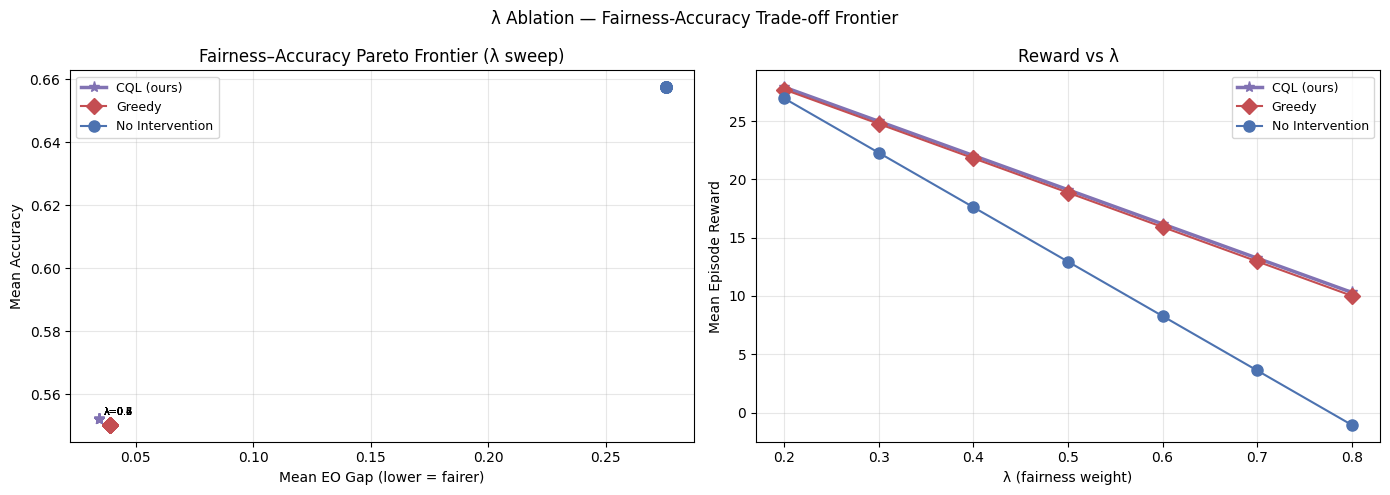

Saved plots/ablation_lambda.png


In [37]:
# ── λ Ablation: evaluate CQL (trained at λ=0.5) in envs with different λ ─
LAMBDA_ABLATION = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
ablation_lambda_results = {name: {"acc": [], "eo_gap": [], "reward": []}
                            for name in ["CQL (ours)", "Greedy", "No Intervention"]}

for lam_val in LAMBDA_ABLATION:
    for name in ablation_lambda_results:
        policy_fn = POLICIES[name]
        lam_env = FairnessEnv(group_probs_dict, max_steps=50, lam=lam_val, seed=99)
        accs, eos, rews = [], [], []
        for ep in range(20):
            state = lam_env.reset(); ep_rew = 0.0; last_info = None
            ep_a, ep_e = [], []
            while True:
                action = policy_fn(state, last_info)
                state, rew, done, info = lam_env.step(action)
                ep_rew += rew
                ep_a.append(info["metrics"]["accuracy"])
                ep_e.append(info["metrics"]["eo_gap"])
                last_info = info
                if done: break
            rews.append(ep_rew)
            accs.append(np.mean(ep_a))
            eos.append(np.mean(ep_e))
        ablation_lambda_results[name]["acc"].append(np.mean(accs))
        ablation_lambda_results[name]["eo_gap"].append(np.mean(eos))
        ablation_lambda_results[name]["reward"].append(np.mean(rews))

# Plot λ ablation: Pareto curve (accuracy vs EO gap as λ varies)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_ab  = {"CQL (ours)": "#8172B3", "Greedy": "#C44E52", "No Intervention": "#4C72B0"}
markers_ab = {"CQL (ours)": "*", "Greedy": "D", "No Intervention": "o"}

for name, res in ablation_lambda_results.items():
    lw = 2.5 if name == "CQL (ours)" else 1.5
    axes[0].plot(res["eo_gap"], res["acc"],
                 marker=markers_ab[name], linewidth=lw, markersize=8,
                 label=name, color=colors_ab[name])
    if name == "CQL (ours)":
        for acc, eo, lv in zip(res["acc"], res["eo_gap"], LAMBDA_ABLATION):
            axes[0].annotate(f"λ={lv}", (eo, acc),
                             textcoords="offset points", xytext=(4, 3), fontsize=7)
axes[0].set_xlabel("Mean EO Gap (lower = fairer)")
axes[0].set_ylabel("Mean Accuracy")
axes[0].set_title("Fairness–Accuracy Pareto Frontier (λ sweep)")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

for name, res in ablation_lambda_results.items():
    lw = 2.5 if name == "CQL (ours)" else 1.5
    axes[1].plot(LAMBDA_ABLATION, res["reward"],
                 marker=markers_ab[name], linewidth=lw, markersize=8,
                 label=name, color=colors_ab[name])
axes[1].set_xlabel("λ (fairness weight)")
axes[1].set_ylabel("Mean Episode Reward")
axes[1].set_title("Reward vs λ")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle("λ Ablation — Fairness-Accuracy Trade-off Frontier", fontsize=12)
plt.tight_layout()
plt.savefig("plots/ablation_lambda.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved plots/ablation_lambda.png")
